# 04 - Baseline ML DOGE/USDT

## Objetivo del notebook

Construir un baseline de machine learning para predecir la dirección futura del precio de DOGE/USDT utilizando features de análisis técnico generadas previamente.

Además de indicadores clásicos como RSI, MACD, ATR o medias móviles, el dataset incorpora nuevas variables relacionadas con soportes y resistencias dinámicas, permitiendo introducir al modelo cierta noción estructural del mercado más allá de indicadores puramente derivados del precio.

El objetivo de este notebook no es construir todavía una estrategia rentable en producción, sino:

- Validar el pipeline de datos.
- Comprobar si existe señal predictiva mínima.
- Comparar varios modelos clásicos.
- Establecer una referencia objetiva antes de pasar a estrategias más complejas.
- Construir una primera aproximación reproducible y libre de data leakage.

Este notebook representa la transición entre la fase de análisis exploratorio y la fase de modelado predictivo del TFM.

In [1]:
# ============================================================
# Imports y carga del dataset
# Se carga el dataset enriquecido generado durante el proceso de feature engineering.
# A partir de este punto, el objetivo ya no es crear variables, sino comprobar si dichas variables contienen suficiente información como para predecir el comportamiento futuro del mercado.
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = Path("../data/processed/DOGEUSDT_5m_binance_2017_2026_features.csv")


df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(723080, 54)


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,...,price_position_in_recent_range,recent_support,recent_resistance,dist_to_nearest_support,dist_to_nearest_resistance,near_support,near_resistance,support_strength,resistance_strength,touch_count_near_level
0,2019-07-06 11:55:00,0.003630,0.003644,0.003630,0.003635,472036.0,2019-07-06 11:59:59.999,1718.044681,24,405943.0,...,0.081048,0.00355,0.004600,0.023411,0.265440,0,0,0.0,0.0,0.0
1,2019-07-06 12:00:00,0.003632,0.003638,0.003629,0.003637,799853.0,2019-07-06 12:04:59.999,2908.008956,18,292138.0,...,0.109846,0.00355,0.004340,0.023867,0.193412,0,0,0.0,0.0,0.0
2,2019-07-06 12:05:00,0.003634,0.003637,0.003625,0.003637,2176492.0,2019-07-06 12:09:59.999,7909.776304,42,1028365.0,...,0.166956,0.00355,0.004069,0.023813,0.118820,0,0,0.0,0.0,0.0
3,2019-07-06 12:10:00,0.003636,0.003636,0.003620,0.003620,618720.0,2019-07-06 12:14:59.999,2240.639784,16,33792.0,...,0.168759,0.00355,0.003964,0.019310,0.095113,0,0,0.0,0.0,0.0
4,2019-07-06 12:15:00,0.003621,0.003627,0.003610,0.003611,1808302.0,2019-07-06 12:19:59.999,6538.506892,30,450314.0,...,0.147272,0.00355,0.003964,0.016893,0.097812,0,0,0.0,0.0,0.0


In [2]:
# ============================================================
# Selección de features y target
# El dataset incluye tanto indicadores técnicos clásicos como nuevas variables estructurales relacionadas con soportes y resistencias.
# Estas features intentan formalizar conceptos tradicionales del análisis técnico utilizando únicamente información histórica disponible en cada instante temporal.
#
# Muy importante:
# Todas las columnas derivadas del futuro deben excluirse explícitamente del entrenamiento.
# Columnas como future_close_x o future_return_x solo existen para construir targets o evaluar retornos posteriores.
# Si se incluyen como features, el modelo estaría viendo información futura y las métricas quedarían completamente contaminadas por data leakage.
# ============================================================

TARGET = "up_1"

# ============================================================
# Explicit columns to exclude
# ============================================================

exclude_cols = [
    "open_time",
    "close_time",

    # Future prices used only to build labels
    "future_close_1",
    "future_close_3",
    "future_close_6",
    "future_close_12",

    # Future returns used only to build labels / evaluate future movement
    "future_return_1",
    "future_return_3",
    "future_return_6",
    "future_return_12",

    # Binary labels
    "up_1",
    "up_3",
    "up_6",
    "up_12"
]

# ============================================================
# Defensive leakage filter
# Exclude any remaining column that clearly refers to future information or labels.
# This protects the notebook if new horizons are added later.
# ============================================================

leakage_patterns = (
    "future_",
    "target_",
    "label_",
    "up_"
)

feature_cols = [
    col for col in df.columns
    if col not in exclude_cols
    and not col.startswith(leakage_patterns)
]

X = df[feature_cols]
y = df[TARGET]

print("Number of features:", len(feature_cols))
print(feature_cols)

# ============================================================
# Leakage sanity check
# ============================================================

leakage_cols_found = [
    col for col in X.columns
    if col.startswith(leakage_patterns)
]

print("Potential leakage columns in X:", leakage_cols_found)

Number of features: 40
['open', 'high', 'low', 'close', 'volume', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume', 'return_prev_1', 'log_return_prev_1', 'sma_20', 'ema_10', 'ema_50', 'ema_200', 'ema10_ema50_ratio', 'ema50_ema200_ratio', 'sma20_ema50_ratio', 'volatility_1h', 'zscore_close_1h', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'bb_mid', 'bb_upper', 'bb_lower', 'bb_width', 'bb_percent', 'atr_14', 'price_position_in_recent_range', 'recent_support', 'recent_resistance', 'dist_to_nearest_support', 'dist_to_nearest_resistance', 'near_support', 'near_resistance', 'support_strength', 'resistance_strength', 'touch_count_near_level']
Potential leakage columns in X: []


In [3]:
# ============================================================
# Split temporal train/test
# Al ser una serie temporal hacemos un split temporal y no aleatorio, mezclar filas aleatoriamente permitiría entrenar con datos “del futuro” y evaluar con datos “del pasado”,
# algo completamente irreal en un entorno financiero.El split temporal intenta simular una situación más cercana al mundo real:
# El modelo aprende del pasado, y predice el futuro.
# ============================================================

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ============================================================
# Scaling
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train shape: (578464, 40)
Test shape: (144616, 40)


## Conclusiones - Split temporal y prevención de leakage

Uno de los aspectos más importantes en proyectos financieros es evitar el denominado *data leakage*.

En problemas de series temporales, realizar un split aleatorio puede introducir información futura dentro del conjunto de entrenamiento, produciendo métricas artificialmente optimistas.

Por este motivo, el dataset se divide respetando el orden cronológico:

- El modelo entrena únicamente con datos pasados.
- La evaluación se realiza sobre datos posteriores.
- El comportamiento se aproxima más a un escenario real de trading.

Aunque este enfoque suele empeorar las métricas frente a un split aleatorio clásico, ofrece resultados mucho más honestos y defendibles desde el punto de vista metodológico.

In [4]:
# ============================================================
# Naive baseline
# El baseline ingenuo sirve como referencia mínima. Si un modelo de machine learning no mejora claramente esta estrategia, entonces no está aportando valor predictivo suficiente.
# En este caso, el baseline representa una regla muy simple: predecir siempre la clase mayoritaria observada en el conjunto de entrenamiento.
# ============================================================

majority_class = y_train.mode()[0]

naive_preds = np.full(shape=len(y_test), fill_value=majority_class)

naive_accuracy = accuracy_score(y_test, naive_preds)
naive_precision = precision_score(y_test, naive_preds, zero_division=0)
naive_recall = recall_score(y_test, naive_preds, zero_division=0)
naive_f1 = f1_score(y_test, naive_preds, zero_division=0)

print("Naive Baseline Metrics")
print("Accuracy :", naive_accuracy)
print("Precision:", naive_precision)
print("Recall   :", naive_recall)
print("F1-score :", naive_f1)

Naive Baseline Metrics
Accuracy : 0.5105520827570946
Precision: 0.0
Recall   : 0.0
F1-score : 0.0


## Conclusiones — Naive baseline

El baseline ingenuo obtiene una accuracy aproximada del 51%, lo que indica que las clases están relativamente equilibradas. Sin embargo, el F1-score es 0 porque el modelo predice únicamente la clase mayoritaria y nunca detecta correctamente movimientos alcistas.

Esto sirve como referencia crítica para el resto del notebook:

- Accuracy ≈ 51% no implica necesariamente capacidad predictiva.
- Un modelo puede parecer “correcto” simplemente explotando el desbalanceo de clases.
- En problemas financieros, métricas como precision, recall y F1-score resultan mucho más informativas.

Este baseline establece el umbral mínimo que cualquier modelo posterior debe superar.

In [5]:
# ============================================================
# Logistic Regression Baseline
# Logistic Regression funciona como primer modelo supervisado interpretable. Al ser un modelo lineal, permite comprobar si existe una relación simple entre las features técnicas y la dirección futura del precio.
# En un problema financiero de muy corto plazo, resultados cercanos al azar no son necesariamente un fallo del código, pueden indicar que la señal predictiva es débil frente al ruido del mercado.
# ============================================================

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

log_preds = log_model.predict(X_test_scaled)

log_accuracy = accuracy_score(y_test, log_preds)
log_precision = precision_score(y_test, log_preds)
log_recall = recall_score(y_test, log_preds)
log_f1 = f1_score(y_test, log_preds)

print(classification_report(y_test, log_preds))

              precision    recall  f1-score   support

           0       0.52      0.69      0.59     73834
           1       0.51      0.34      0.41     70782

    accuracy                           0.52    144616
   macro avg       0.52      0.51      0.50    144616
weighted avg       0.52      0.52      0.50    144616



## Conclusiones — Logistic Regression

Logistic Regression obtiene un comportamiento relativamente equilibrado dentro del contexto del problema.

Las métricas muestran:

- Accuracy cercana al 51.8%.
- Precision alrededor del 51%.
- Recall aproximado del 33%.
- F1-score cercano a 0.41.

Aunque sigue siendo un modelo lineal relativamente simple, consigue detectar una proporción razonable de movimientos alcistas reales.

Este resultado es interesante porque sugiere que parte de las nuevas features estructurales sí contienen información linealmente explotable.

En otras palabras:

- Variables como distancia a soportes o posición dentro del rango reciente parecen introducir cierta señal direccional.
- Incluso un modelo simple es capaz de aprovechar parcialmente esa información.

Aun así, el rendimiento global sigue siendo modesto y muy cercano al azar estadístico, algo completamente habitual en predicción financiera intradía.

In [6]:
# ============================================================
# Random Forest Baseline
# Random Forest permite capturar relaciones no lineales entre variables técnicas. Esto puede ser útil cuando la señal no se expresa como una relación lineal simple.
# ============================================================

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds)
rf_recall = recall_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)

print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.52      0.76      0.62     73834
           1       0.52      0.26      0.35     70782

    accuracy                           0.52    144616
   macro avg       0.52      0.51      0.48    144616
weighted avg       0.52      0.52      0.49    144616



## Conclusiones — Random Forest

Random Forest obtiene un rendimiento moderado y relativamente conservador dentro del conjunto de modelos evaluados.

Las métricas obtenidas muestran:

- Accuracy cercana al 51.9%.
- Precision alrededor del 52%.
- Recall aproximado del 26%.
- F1-score cercano a 0.35.

Aunque sigue detectando relaciones no lineales entre variables, el modelo se vuelve más conservador y reduce significativamente su capacidad para detectar movimientos alcistas.

El comportamiento observado sugiere que la complejidad adicional introducida por algunas variables estructurales no siempre se traduce automáticamente en una mejora del rendimiento.

Probablemente estén ocurriendo varias cosas simultáneamente:

- Algunas nuevas features pueden aportar ruido adicional.
- Existen variables parcialmente redundantes.
- El modelo podría estar repartiendo importancia entre demasiadas señales débiles.
- La nueva información estructural quizá no sea tan estable temporalmente como parecía inicialmente.

De hecho, los resultados ilustran uno de los problemas clásicos del machine learning financiero: Más features no implica necesariamente mejores modelos.

En datasets extremadamente ruidosos, añadir señales marginales puede incluso degradar parcialmente la generalización del modelo.

Top 20 most important features
                           feature  importance
19                 zscore_close_1h    0.078131
28                      bb_percent    0.077777
10               log_return_prev_1    0.069751
9                    return_prev_1    0.066450
6                 number_of_trades    0.054403
4                           volume    0.052834
5               quote_asset_volume    0.052669
29                          atr_14    0.040438
20                          rsi_14    0.037496
8     taker_buy_quote_asset_volume    0.028854
7      taker_buy_base_asset_volume    0.024757
23                       macd_hist    0.024565
34      dist_to_nearest_resistance    0.022015
21                            macd    0.021906
15               ema10_ema50_ratio    0.021385
27                        bb_width    0.018197
30  price_position_in_recent_range    0.017860
25                        bb_upper    0.017799
17               sma20_ema50_ratio    0.017507
22                     macd_s

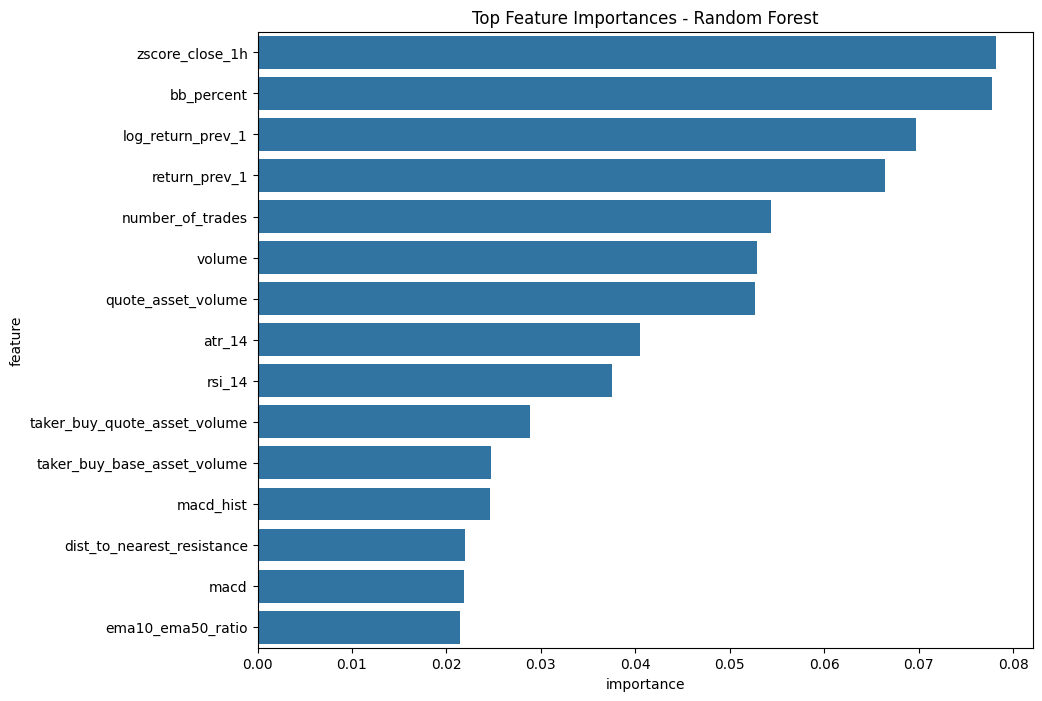

In [7]:
# ============================================================
# Feature importance
# La importancia de variables ayuda a interpretar qué indicadores influyen más en las predicciones del Random Forest.
# ============================================================

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("Top 20 most important features")
print(importance_df.head(20))

plt.figure(figsize=(10, 8))

sns.barplot(
    data=importance_df.head(15),
    x="importance",
    y="feature"
)

plt.title("Top Feature Importances - Random Forest")
plt.show()

## Conclusiones — Importancia de variables

El análisis de importancia de variables permite identificar qué indicadores técnicos contribuyen más al proceso de decisión del modelo.

Los resultados muestran algo especialmente interesante:

- Features clásicas como zscore_close_1h, RSI, ATR, retornos recientes y volumen siguen dominando gran parte de la señal predictiva.
- Sin embargo, algunas nuevas variables estructurales sí aparecen dentro del top de importancia.

En particular destaca:

- dist_to_nearest_resistance
- price_position_in_recent_range

Esto sugiere que el modelo sí está utilizando parcialmente información relacionada con estructura de mercado y niveles técnicos.

No obstante, la importancia relativa de estas variables sigue siendo moderada frente a indicadores clásicos de momentum y volatilidad.

Esto puede interpretarse de varias formas:

- Las features de soporte/resistencia contienen cierta señal útil.
- Esa señal probablemente es débil y contextual.
- El modelo todavía no consigue explotarla de forma especialmente eficiente.

Este punto resulta especialmente relevante para futuras iteraciones del proyecto:

- Puede ser necesario refinar cómo se calculan soportes y resistencias.
- O introducir contexto temporal/regime-aware más avanzado.
- O incluso delegar parte de esta interpretación estructural a modelos secuenciales o aprendizaje por refuerzo.

In [8]:
# ============================================================
# XGBoost
# XGBoost suele considerarse uno de los modelos baseline más potentes para datos tabulares y competiciones de machine learning.
# Combina múltiples árboles de decisión de forma secuencial, corrigiendo progresivamente los errores de los árboles anteriores.
# En datasets financieros suele funcionar especialmente bien cuando existen relaciones complejas y señales débiles mezcladas con mucho ruido.
# ============================================================

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_preds)
xgb_precision = precision_score(y_test, xgb_preds)
xgb_recall = recall_score(y_test, xgb_preds)
xgb_f1 = f1_score(y_test, xgb_preds)

print(classification_report(y_test, xgb_preds))

              precision    recall  f1-score   support

           0       0.52      0.61      0.56     73834
           1       0.51      0.42      0.46     70782

    accuracy                           0.52    144616
   macro avg       0.51      0.51      0.51    144616
weighted avg       0.51      0.52      0.51    144616



## Conclusiones — XGBoost

XGBoost continúa siendo el modelo con mejor equilibrio global del notebook.

Las métricas obtenidas muestran:

- Accuracy cercana al 51.6%.
- Precision alrededor del 50.7%.
- Recall aproximado del 41.7%.
- F1-score cercano a 0.46.

El modelo mantiene el comportamiento más estable y equilibrado entre los modelos evaluados.

Esto resulta bastante coherente con la naturaleza de XGBoost:

- Tolera relativamente bien datasets con ruido.
- Maneja mejor relaciones complejas y débiles.
- Tiende a generalizar mejor que Random Forest cuando existen muchas variables parcialmente redundantes.

Esto resulta coherente con la naturaleza de los mercados financieros intradía:

- Muchas señales aparentemente intuitivas contienen una capacidad predictiva extremadamente limitada.
- Gran parte del comportamiento del mercado está dominado por ruido.
- Pequeñas mejoras métricas pueden requerir modelos capaces de manejar relaciones complejas y señales débiles.

Aun así, el modelo sigue detectando una proporción relevante de movimientos alcistas y mantiene el mejor compromiso global entre precision y recall.

Por este motivo, XGBoost continuará utilizándose como baseline principal para las siguientes fases de backtesting.

In [9]:
# ============================================================
# Model comparison
# La comparación final permite evaluar si los modelos realmente aportan valor respecto al baseline ingenuo.
# En problemas financieros, pequeñas mejoras sobre el baseline pueden ser relevantes, pero deben interpretarse con cautela.
# Lo importante en esta fase no es demostrar rentabilidad, sino construir una referencia honesta y libre de leakage.
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        naive_accuracy,
        log_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        naive_precision,
        log_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        naive_recall,
        log_recall,
        rf_recall,
        xgb_recall
    ],
    "F1-score": [
        naive_f1,
        log_f1,
        rf_f1,
        xgb_f1
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1-score
0       Naive Baseline  0.510552   0.000000  0.000000  0.000000
1  Logistic Regression  0.518442   0.512253  0.336964  0.406518
2        Random Forest  0.519106   0.517091  0.264375  0.349871
3              XGBoost  0.515987   0.506741  0.417352  0.457723


## Conclusiones — Comparativa global de modelos

La comparación muestra que todos los modelos supervisados superan ligeramente al baseline ingenuo, aunque las diferencias absolutas siguen siendo pequeñas.

Los resultados reflejan perfectamente uno de los grandes problemas del machine learning aplicado a trading:

- El mercado contiene cierta señal predictiva.
- Esa señal es extremadamente débil.
- El ruido domina gran parte del comportamiento del precio.

Los distintos modelos muestran comportamientos claramente diferenciados:

- Logistic Regression presenta un comportamiento relativamente equilibrado pese a su simplicidad.
- Random Forest tiende a un comportamiento más conservador.
- XGBoost mantiene el mejor equilibrio global entre precision y recall.

Esto sugiere que las señales presentes en el dataset combinan componentes lineales, relaciones no lineales débiles y una elevada cantidad de ruido.

Este resultado es metodológicamente muy interesante para el TFM porque refleja un comportamiento realista del desarrollo de sistemas financieros: Añadir más indicadores no garantiza mejorar el rendimiento.

De hecho, una parte importante del trabajo en trading algorítmico consiste precisamente en:

- eliminar ruido,
- simplificar señales,
- reducir redundancia,
- y evitar sobreajuste.

Por este motivo, las siguientes fases del proyecto se centrarán no solo en añadir complejidad, sino también en validar rigurosamente qué señales aportan valor real mediante backtesting y evaluación financiera.

En otras palabras: este notebook demuestra que existe una señal mínima explotable, pero todavía no demuestra que dicha señal pueda transformarse en una estrategia rentable y estable.

In [10]:
# ============================================================
# Save trained models
# Esta celda serializa los modelos entrenados utilizando joblib, permitiendo reutilizarlos posteriormente sin necesidad de volver a entrenar.
# Además del modelo en sí, se guardan también las columnas utilizadas como features, y el target empleado durante el entrenamiento.
# Esto resulta especialmente útil para las siguientes fases del proyecto, como el backtesting, la generación de señales o la integración con un sistema automatizado de trading.
# ============================================================

import joblib

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump({
    "model": log_model,
    "feature_cols": feature_cols,
    "target": TARGET
}, MODELS_DIR / "logistic_regression.joblib")

joblib.dump({
    "model": rf,
    "feature_cols": feature_cols,
    "target": TARGET
}, MODELS_DIR / "random_forest.joblib")

joblib.dump({
    "model": xgb_model,
    "feature_cols": feature_cols,
    "target": TARGET
}, MODELS_DIR / "xgboost.joblib")

print("Models saved successfully")

Models saved successfully


## Conclusión final del notebook

Este notebook representa la primera validación formal del enfoque de machine learning supervisado dentro del proyecto.

El objetivo principal no era construir todavía un sistema rentable, sino responder varias preguntas fundamentales:

- ¿Existe señal predictiva en las features generadas?
- ¿El pipeline está libre de leakage?
- ¿Los modelos son capaces de superar un baseline trivial?
- ¿Qué tipo de arquitectura se adapta mejor al problema?

Los resultados sugieren que sí existe cierta capacidad predictiva, aunque limitada.

Sin embargo, también dejan claro uno de los puntos más importantes del trading algorítmico: Predecir ligeramente mejor que el azar no garantiza ganar dinero.

El comportamiento del mercado está dominado por ruido, cambios de régimen, volatilidad extrema y costes implícitos de operación.

Por este motivo, la siguiente fase del TFM se centrará en trasladar estas predicciones a un entorno mucho más realista mediante backtesting:

- Simulación cronológica.
- Gestión dinámica de posiciones.
- Stop loss y take profit basados en ATR.
- Filtros de volatilidad.
- Control de exposición.
- Threshold tuning.
- Evaluación financiera real.

En definitiva, este notebook establece una base sólida y metodológicamente correcta sobre la que construir el resto del sistema de trading algorítmico del proyecto.